<a href="https://colab.research.google.com/github/rebeccalordan-perret/plots-model-comparison/blob/main/cross_comparison_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import subprocess
import sys
import logging
import os

# get rid of the non-installed font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


# If it is run for the first time, we need install the repo and restart the notebook
repo_path = "/content/plots-model-comparison"

if os.path.exists(repo_path):
    # pull updates
    result = subprocess.run(
        ["git", "-C", repo_path, "pull"],
        capture_output=True,
        text=True
    )
else:
    # clone repo if missing
    result = subprocess.run(
        ["git", "clone",
         "https://github.com/sweet-cross/plots-model-comparison",
         repo_path],
        capture_output=True,
        text=True
    )
print(result)
# Check if successful (exit code 0 means success)
if result.returncode == 0:
    sys.path.insert(0,'/content/plots-model-comparison')
    from cross_tools.plots import Plots
else:
    # add the package to the path
    print("⚠️ Please restart the runtime to use the cloned repository.")
    print("   Go to: Runtime → Restart Session")


CompletedProcess(args=['git', '-C', '/content/plots-model-comparison', 'pull'], returncode=0, stdout='Updating 383c8ef..cbc82de\nFast-forward\n results/nuclear_2026_19_02.csv | 1626 +++++++++++++++++++++-------------------\n 1 file changed, 834 insertions(+), 792 deletions(-)\n', stderr='From https://github.com/sweet-cross/plots-model-comparison\n   383c8ef..cbc82de  main       -> origin/main\n')


### initialize the plotting tool

In [21]:

#  List of files with:
# name: name to be displayed in the plots
# id:  model_id in CROSSHub
# summer: name of the summer day reported by the model
# summerDay: data of the summer typical day in the format dd.mm.yyyy
# winter: name of the winter day reported by the model
# winterDay: data of the winter typical day in the format dd.mm.yyyy
# color: color used for the scatter plots in hex

# color: color to be used for the model in scatter plots
model_list =  [
          #{'name': 'Calliope', 'file': 'resultsCross_Calliope','summer':'Jul 20','winter':'Feb 08','color':'#D57CBE'},
          #{'name': 'Expanse', 'file': 'resultsCross_Expanse','summer':'Jul 02','winter':'Jan 01','color':'#FF7D0D'},
          {'name': 'Nexus-e', 'id':'nexuse','summer':'Typical day','summerDay':'02.07.2050','winter':'Typical day','winterDay':'08.02.2050','color':'#BCBD21'},
          #{'name': 'SecMod', 'id': 'secmod','summer':'Typical day','summerDay':'01.07.2050','winter':'Typical day','winterDay':'01.02.2050','color':'#9565BD'},
          {'name': 'SES', 'id':'ses','summer':'Typical day','summerDay':'01.08.2050','winter':'Typical day','winterDay':'01.02.2050','color':'#1E75B3'},
          {'name': 'SES-ETH', 'id': 'seseth','summer':'Typical day','summerDay':'01.07.2050','winter':'Typical day','winterDay':'01.02.2050','color':'#2A9E2A'},
          {'name': 'STEM', 'id': 'stem','summer':'Week day','summerDay':'01.07.2050','winter':'Week day','winterDay':'01.02.2050','color':'#D52426'},
          # {'name': 'ZEN-Garden','id':'zengarden', 'summer':'Week day','summerDay':'01.07.2050','winter':'Week day','winterDay':'01.02.2050','color':'#00BFC4'},
         #{'name': 'Empa', 'file': 'resultsCross_VSE','summer':'Jul 11','winter':'Feb 15','color':'#8B5349'},
          #{'name': 'EP2050+\nZero Basis', 'file': 'resultsCross_EP','summer':'avg. Aug. 13-19','winter':'avg. Feb. 7-13','color':'#7F7F7F'}
          ]

# Create the object that produces the plots and processes the data
# Name of the csv file with the results
fileResults = "/content/plots-model-comparison/results/nuclear_2026_19_02"
# Scenario names and corresponding colors
sce = ['abroad-resnuc-high','abroad-resnuc-medium','abroad-resnuc-low','abroad-resnuc-phaseout','abroad-res-high','abroad-res-medium','abroad-res-low','abroad-res-phaseout','abroad-nores-high','abroad-nores-medium','abroad-nores-low','abroad-nores-phaseout']
sceColors = ['#9FBA3D','#E9442E','#EC9235','#3F89BD','#8E44AD','#1ABC9C','#F1C40F','#34495E','#9FBA3D','#E9442E','#EC9235','#3F89BD','#8E44AD','#1ABC9C','#F1C40F','#34495E']
# Folders where the plots will be created
folder_plots='plots'


cross_plots = Plots(fileResults,model_list,sce,sceColors,folder_plots)


/content/plots-model-comparison/cross_tools/plots.py:183: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mask_hourly, 'timestamp'] = (


=== Plots object initialized ===

Attributes:
  models: dict
  modelsid: list
  model_colors: list
  typicalDays: dict
  folder_plots: str
  allData: DataFrame
  yearsModel: dict
  sce: list
  sceColors: list
  sceModel: dict
  sceVariants: list
  annualData: DataFrame

Methods:
  plotBarHorizontal()
  plotBarHorizontalSigned()
  plotBarVertical()
  plotBarVerticalSigned()
  plotBarVerticalSignedFuels()
  plotHourlySignedProfile()
  plotLineByScenario()
  plotScatter()
  plotTechDist()




### Annual electricity supply with net imports

In [30]:
# Annual electricity supply with net imports

# name: name of the technology or group of technologies (valid names: https://sweet-cross.github.io/instructions-data/docs/sets/tech_generation/)
# data: list with the technologies that correspond to this category
# color: color to use for this category
varList_supply_net = [
    {'name':'Hydro','data':['hydro_dam','hydro_ror'],'color':'#0377CA'},
    {'name':'Nuclear','data':['nuclear'],'color':'#FF007F'},
    {'name':'Solar','data':['spv'],'color':'#FAC748'},
    {'name':'Wind','data':['wind'],'color':'#F2960E'},
    {'name':'Geothermal','data':['geothermal_pp'],'color':'#ac79c4'},
    {'name':'Methane','data':["methane_pp",'fuel_cell_methane'],'color':'#1f6228'},
    {'name':'Hydrogen','data':['hydrogen_pp','fuel_cell_h2'],'color':'#03CBA0'},
    {'name':'Liquids','data':['liquids_pp'],'color':'#4B4EFC'},
    {'name':'Waste','data':['waste_pp'],'color':'#b82222'},
    {'name':'Wood','data':['wood_pp'],'color':'#a9807c'},
    {'name':'Storage','data':['net_storage_out'],'color':'#939CAC'},
    {'name':'Net-imports','data':['net_imports'],'color':'#CCCCCC'}
    #     {'name':'Storage','data':['battery_out','phs_out'],'color':'#939CAC'},
    #     {'name':'Imports','data':['imports'],'color':'#CCCCCC'}
   ]

varName = 'electricity_supply'
listModels = cross_plots.modelsid
xlabel = 'Electricity (TWh)'
xmax = 130
fileName = 'elecSupply_tech_net'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-phaseout','wacc_5'):'Phase-out',
        ('abroad-res-high','wacc_5'):'High cost',
        ('abroad-res-medium','wacc_5'):'Medium cost',
        ('abroad-res-low','wacc_5'):'Low cost',
    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-out',
        ('abroad-resnuc-high','wacc_5'):'High cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium cost',
        ('abroad-resnuc-low','wacc_5'):'Low cost',
    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-phaseout','wacc_5'):'Phase-out',
        ('abroad-nores-high','wacc_5'):'High cost',
        ('abroad-nores-medium','wacc_5'):'Medium cost',
        ('abroad-nores-low','wacc_5'):'Low cost',
    },
    }

for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=listModels,
        listSce=scenarios,
        varName = varName,
        varList=varList_supply_net,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name,
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 57)

### Annual electricity consumption/use

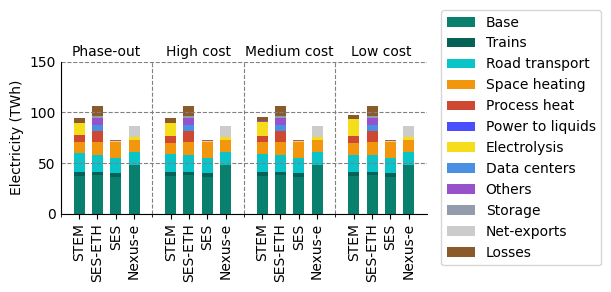

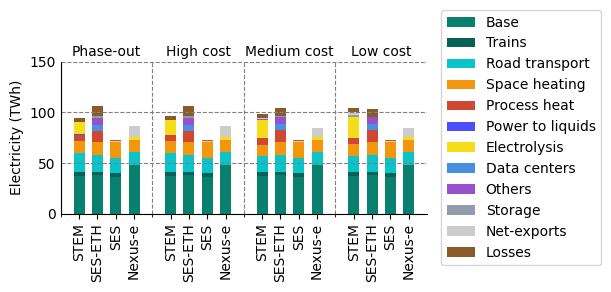

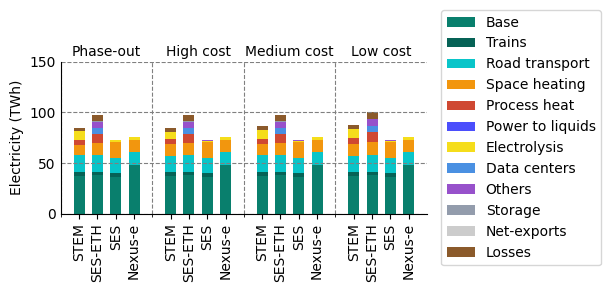

In [27]:
# Electricity consumption by use with net exports
# Available variables: https://sweet-cross.github.io/instructions-data/docs/sets/use_elec/
varList_use_net = [
    {'name':'Base','data':['elec_appliances'],'color':'#097F6D'},
    {'name':'Trains','data':['passenger_rail','freight_rail'],'color':'#066256'},
    {'name':'Road transport','data':['road_public','road_private','truck','ldv'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating_boiler_electrode','space_heating_heater_elec','space_heating_heat_pump'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat_boiler_electrode','process_heat_heater_elec','process_heat_heat_pump'],'color':'#CF4832'},
    {'name':'Power to liquids','data':['power_to_liquid'],'color':'#4B4EFC'},
    {'name':'Electrolysis','data':['electrolysis'],'color':'#F5DD1B'},
    {'name': 'Data centers', 'data': ['data_centers'], 'color': '#4A90E2'},
    {'name':'Others','data':['dac','data_centers'],'color':'#9751CB'},
 #  {'name':'Storage','data':['battery_in','phs_in'],'color':'#939CAC'},
 #  {'name':'Exports','data':['exports'],'color':'#CCCCCC'},
    {'name':'Storage','data':['net_storage_in'],'color':'#939CAC'},
    {'name':'Net-exports','data':['net_exports'],'color':'#CCCCCC'},
    {'name':'Losses','data':['grid_losses','storage_losses'],'color':'#8B5A2B'}
    ]

varName = 'electricity_consumption'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Electricity (TWh)'
xmax = 150
fileName = 'elecUse_net'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-phaseout','wacc_5'):'Phase-out',
        ('abroad-res-high','wacc_5'):'High cost',
        ('abroad-res-medium','wacc_5'):'Medium cost',
        ('abroad-res-low','wacc_5'):'Low cost',
    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-out',
        ('abroad-resnuc-high','wacc_5'):'High cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium cost',
        ('abroad-resnuc-low','wacc_5'):'Low cost',
    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-phaseout','wacc_5'):'Phase-out',
        ('abroad-nores-high','wacc_5'):'High cost',
        ('abroad-nores-medium','wacc_5'):'Medium cost',
        ('abroad-nores-low','wacc_5'):'Low cost',
    },
    }


for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=listModels,
        listSce=scenarios,
        varName = varName,
        varList=varList_use_net,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name,
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )




### Capacity vs. OCC nuclear vs. WACC

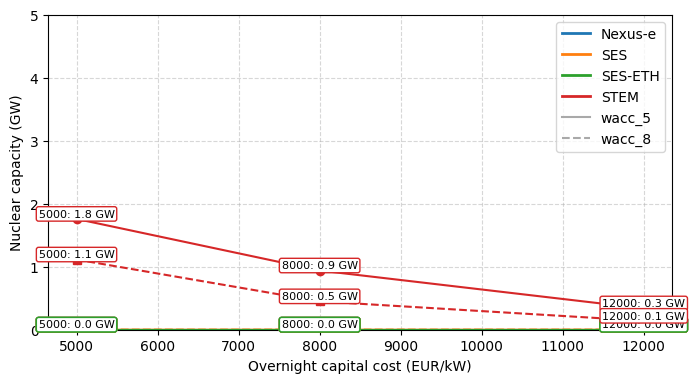

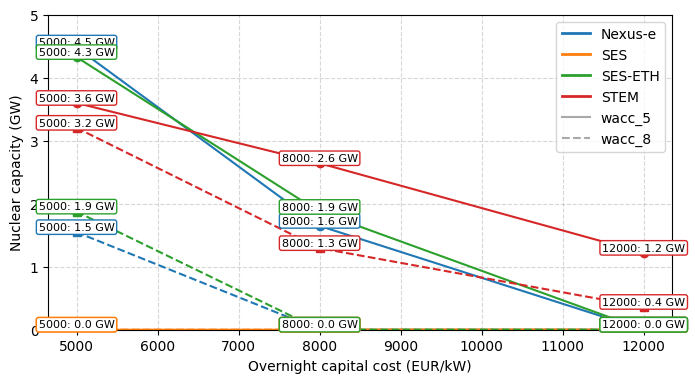

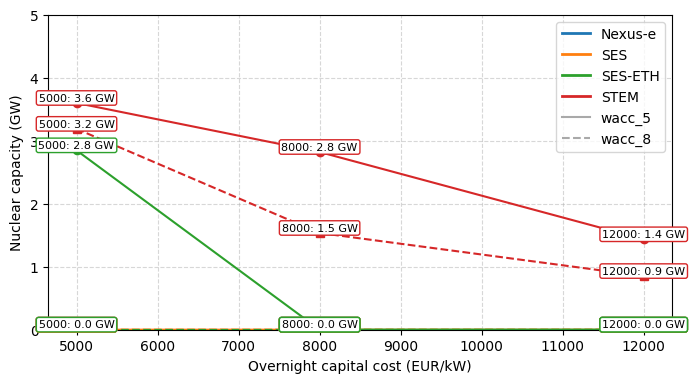

In [23]:
#### Capacity vs. cost plot


scenario_groups = {
    "res": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-res-high','wacc_5'):('wacc_5',12000),
                ('abroad-res-medium','wacc_5'):('wacc_5',8000),
                ('abroad-res-low','wacc_5'):('wacc_5',5000),
                ('abroad-res-high','wacc_8'):('wacc_8',12000),
                ('abroad-res-medium','wacc_8'):('wacc_8',8000),
                ('abroad-res-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
   #         ('abroad-res-high',   'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-medium', 'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-low',    'wacc_8', 'nexuse'): 0.0,
  #           ('abroad-res-high',   'wacc_8', 'stem'): 0.4,
  #            ('abroad-res-medium', 'wacc_8', 'stem'): 1.1,
  #            ('abroad-res-low',    'wacc_8', 'stem'): 1.4,
  #            ('abroad-res-high',   'wacc_5', 'stem'): 0.7,
  #            ('abroad-res-medium', 'wacc_5', 'stem'): 1.4,
  #            ('abroad-res-low',    'wacc_5', 'stem'): 2.4,
        },
    },
    "resnuc": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-resnuc-high','wacc_5'):('wacc_5',12000),
                ('abroad-resnuc-medium','wacc_5'):('wacc_5',8000),
                ('abroad-resnuc-low','wacc_5'):('wacc_5',5000),
                ('abroad-resnuc-high','wacc_8'):('wacc_8',12000),
                ('abroad-resnuc-medium','wacc_8'):('wacc_8',8000),
                ('abroad-resnuc-low','wacc_8'):('wacc_8',5000),
            },
        "extra_values": {
    #        ('abroad-resnuc-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-resnuc-medium', 'wacc_8', 'nexuse'): 0.4,
    #        ('abroad-resnuc-low',    'wacc_8', 'nexuse'): 1.63,
    #        ('abroad-resnuc-high',   'wacc_8', 'stem'): 0.4,
    #        ('abroad-resnuc-medium', 'wacc_8', 'stem'): 1.7,
    #        ('abroad-resnuc-low',    'wacc_8', 'stem'): 2.8,
    #        ('abroad-resnuc-high',   'wacc_5', 'stem'): 1.4,
   #         ('abroad-resnuc-medium', 'wacc_5', 'stem'): 2.3,
    #        ('abroad-resnuc-low',    'wacc_5', 'stem'): 3.6,
        },
    },
    "nores": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-nores-high','wacc_5'):('wacc_5',12000),
                ('abroad-nores-medium','wacc_5'):('wacc_5',8000),
                ('abroad-nores-low','wacc_5'):('wacc_5',5000),
                ('abroad-nores-high','wacc_8'):('wacc_8',12000),
                ('abroad-nores-medium','wacc_8'):('wacc_8',8000),
                ('abroad-nores-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
    #        ('abroad-nores-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-medium', 'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-low',    'wacc_8', 'nexuse'): 0.0,
    #          ('abroad-nores-high',   'wacc_8', 'stem'): 0.8,
    #          ('abroad-nores-medium', 'wacc_8', 'stem'): 1.7,
    #          ('abroad-nores-low',    'wacc_8', 'stem'): 3.3,
   #           ('abroad-nores-high',   'wacc_5', 'stem'): 1.5,
    #          ('abroad-nores-medium', 'wacc_5', 'stem'): 3.3,
    #          ('abroad-nores-low',    'wacc_5', 'stem'): 3.6,
        },
    },
}


listModels = cross_plots.modelsid #any model can be excluded, the list should include the model ids
varName = 'installed_capacity'
use_technology_fuel = 'nuclear'
xlabel = 'Overnight capital cost (EUR/kW)'
ylabel = 'Nuclear capacity (GW)'
fileName = 'nucCap_occ'
year = 2050

for group_name, cfg in scenario_groups.items():

    cross_plots.plotLineByScenario(
        listModelsid = listModels,
        map_sce_xaxis = cfg["map_sce_xaxis"],
        varName = varName,
        use_technology_fuel = use_technology_fuel,
        year = year,
        scale = 1,  # if values are MW → GW, etc.
        xlabel = xlabel,
        ylabel = ylabel,
        fileName = fileName+'_'+group_name,
        width = 18,
        height = 10,
        ylim = (0,5),
        extra_values        = cfg["extra_values"],
    )

# Capacity vs. OCC side-by-side graphs

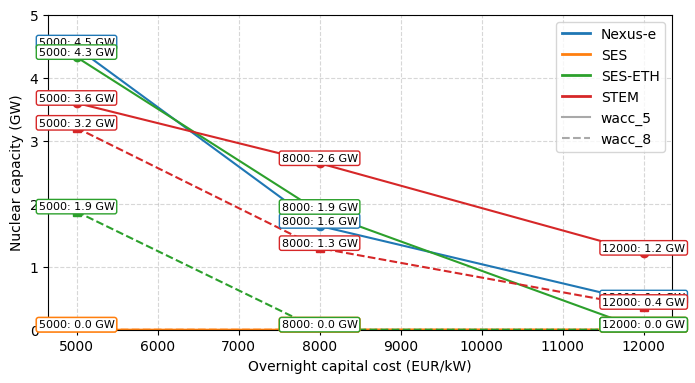

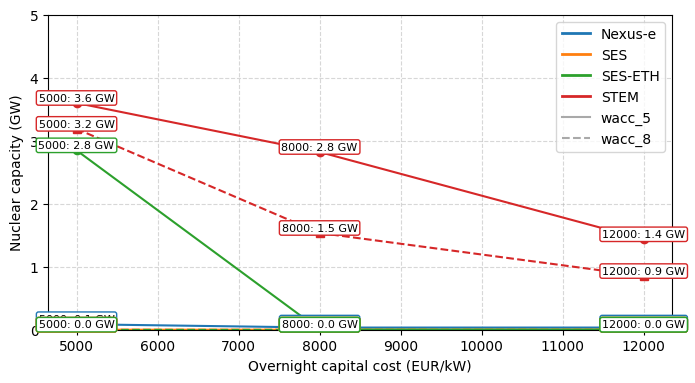

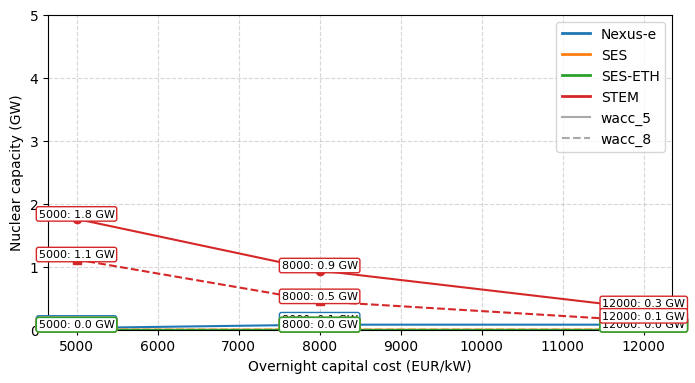

In [ ]:

listModels = cross_plots.modelsid #any model can be excluded, the list should include the model ids
varName = 'installed_capacity'
use_technology_fuel = 'nuclear'
xlabel = 'Overnight capital cost (EUR/kW)'
ylabel = 'Nuclear capacity (GW)'
fileName = 'nucCap_occ'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-phaseout','wacc_5'):'Phase-out',
        ('abroad-res-high','wacc_5'):'High cost',
        ('abroad-res-medium','wacc_5'):'Medium cost',
        ('abroad-res-low','wacc_5'):'Low cost',
    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-out',
        ('abroad-resnuc-high','wacc_5'):'High cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium cost',
        ('abroad-resnuc-low','wacc_5'):'Low cost',
    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-phaseout','wacc_5'):'Phase-out',
        ('abroad-nores-high','wacc_5'):'High cost',
        ('abroad-nores-medium','wacc_5'):'Medium cost',
        ('abroad-nores-low','wacc_5'):'Low cost',
    },
    }

for group_name, cfg in scenario_groups.items():

    cross_plots.plotLineByScenario(
        listModelsid = listModels,
        map_sce_xaxis = cfg["map_sce_xaxis"],
        varName = varName,
        use_technology_fuel = use_technology_fuel,
        year = year,
        scale = 1,  # if values are MW → GW, etc.
        xlabel = xlabel,
        ylabel = ylabel,
        fileName = fileName+'_'+group_name,
        width = 18,
        height = 10,
        ylim = (0,5),
        extra_values        = cfg["extra_values"],
    )



### Hydrogen Production

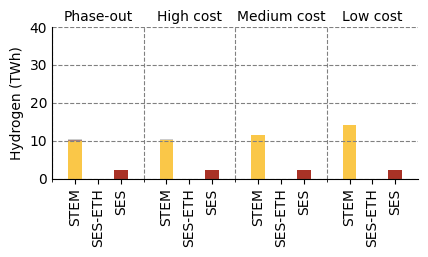

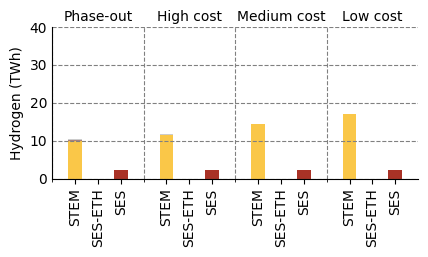

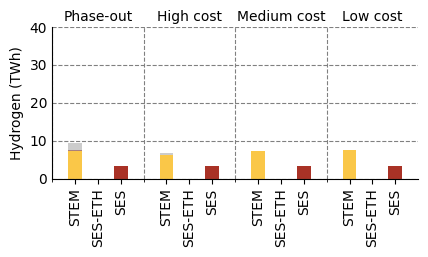

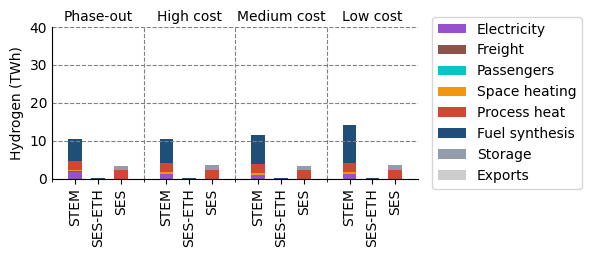

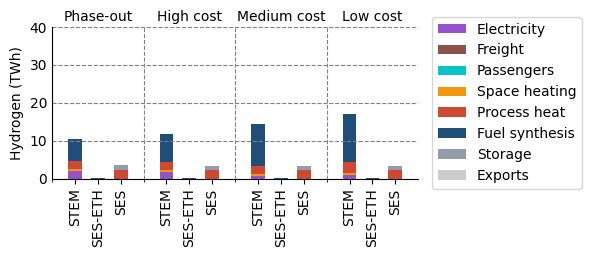

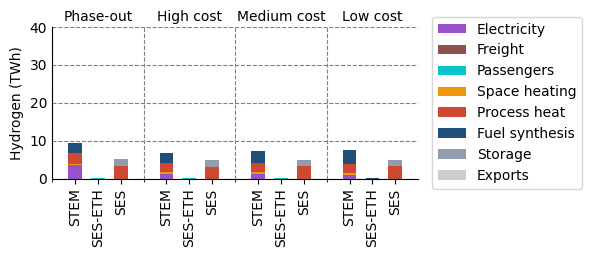

In [24]:
# Hydrogen supply by technology https://sweet-cross.github.io/instructions-data/docs/sets/tech_hydrogen/
varList_h2_supply = [
    {'name':'Electrolysis','data':['electrolyser'],'color':'#FAC748'},
    {'name':'Steam reforming','data':['steam_reforming'],'color':'#1f6228'},
    {'name':'Gasification','data':['wood_gasification_h2','waste_gasification_h2'],'color':'#a9807c'},
    {'name':'Pyrolysis','data':['methane_pyrolysis'],'color':'#A93226'},
    {'name':'Imports','data':['imports'],'color':'#CCCCCC'}
    ]

varName = 'h2_supply'
listModels = cross_plots.modelsid
xlabel = 'Hydrogen (TWh)'
xmax = 40
fileName = 'h2Supply_tech'
year = 2050

for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=['ses','seseth', 'stem'],
        listSce=scenarios,
        varName = varName,
        varList=varList_h2_supply,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name,
        invert=False, legend=False, pos_legend="upper right",
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )


varList_h2_consump = [
    {'name':'Electricity','data':['hydrogen_pp','fuel_cell_h2'],'color':'#9751CB'},
    {'name':'Freight','data':['truck','ldv'],'color':'#8B5349'},
    {'name':'Passengers','data':['passenger_road_public','passenger_road_private'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat'],'color':'#CF4832'},
    {'name':'Fuel synthesis','data':['fuel_synthesis'],'color':'#1F4E79'},
     {'name':'Storage','data':['storage'],'color':'#939CAC'},
    {'name':'Exports','data':['exports'],'color':'#CCCCCC'}
    ]

varName = 'h2_fec'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Hydrogen (TWh)'
xmax = 40
fileName = 'h2Use'
year = 2050
for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=['ses','seseth','stem'],
        listSce=scenarios,
        varName = varName,
        varList=varList_h2_consump,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name,
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )

Within Model System Costs Changes

In [18]:
#Calculate relative cost changes
varName ='total_system_costs'

listModels = cross_plots.modelsid
year=2050

# Get only the costs from the annual data
costs = cross_plots.annualData.loc[(slice(None),slice(None),slice(None),varName,'','annual',year)]
# Reshape the dataframe so we have one scenario variant per column
costs = costs.unstack(level=[1,0]).droplevel(level=0,axis=1)
costs_change = costs.copy()

variant_list = ['wacc_5','wacc_8']

scenario_groups = {
'res': {'base': 'abroad-res-phaseout','compare': ['abroad-res-low','abroad-res-medium','abroad-res-high']},
'resnuc': {'base': 'abroad-resnuc-phaseout','compare': ['abroad-resnuc-low','abroad-resnuc-medium','abroad-resnuc-high']},
'nores': {'base': 'abroad-nores-phaseout','compare': ['abroad-nores-low','abroad-nores-medium','abroad-nores-high']},
}

for variant in variant_list:
  for name, scenarios in scenario_groups.items():
    base_scenario = scenarios['base']
    cost_base = costs.loc[:,(variant,base_scenario)]
    costs_change.loc[:,(variant,base_scenario)] = 0
    for s in scenarios['compare']:
      costs_change.loc[:,(variant,s)] = 100*(costs_change.loc[:,(variant,s)]-cost_base)/cost_base

print(costs_change)
# Export to csv
costs_change.to_csv('cost_change.csv')

scenario_variant            wacc_5            wacc_8           wacc_5  \
scenario_name    abroad-nores-high abroad-nores-high abroad-nores-low   
model                                                                   
ses                      -0.008486          0.000779        -0.008582   
seseth                    0.001140          0.001784        -0.517079   
stem                     -0.827374         -0.807460        -1.100983   

scenario_variant           wacc_8              wacc_5              wacc_8  \
scenario_name    abroad-nores-low abroad-nores-medium abroad-nores-medium   
model                                                                       
ses                     -0.002804           -0.007200           -0.003875   
seseth                  -0.001353            0.000000            0.000000   
stem                    -0.934924           -1.021593           -0.898844   

scenario_variant                wacc_5                wacc_8          wacc_5  \
scenario_name    a

### Liquids use - Bar plot by model and use

In [10]:
# Liquids consumption by use https://sweet-cross.github.io/instructions-data/docs/sets/use_liquids/

varList_liquids_consump = [
    {'name':'Electricity','data':['elec_generation'],'color':'#9751CB'},
    {'name':'Freight','data':['truck','ldv'],'color':'#8B5349'},
    {'name':'Passengers','data':['passenger_road_public','passenger_road_private'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat'],'color':'#CF4832'},
    {'name':'Fuel syntheis','data':['fuel_synthesis'],'color':'#1F4E79'},
     {'name':'Storage','data':['storage'],'color':'#939CAC'},
    {'name':'Exports','data':['exports'],'color':'#CCCCCC'}
    ]

varName = 'liquids_fec'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Liquid fuels (TWh)'
xmax = 50
fileName = 'liquidsUse.pdf'
right = True #True if model names have to go on the right, it invers the axis
legend = True # True if legend has to be displayed
#pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
onTopVarName = ''
year = '2050'
height=15
width=7
cross_plots.plotBar(listModels,varName,varList_liquids_consump,year,scale,xlabel,xmax,fileName,right,legend,pos_legend,onTopVarName,width,height)


IndentationError: unexpected indent (ipython-input-1265921885.py, line 23)

## Electricity Imports

res


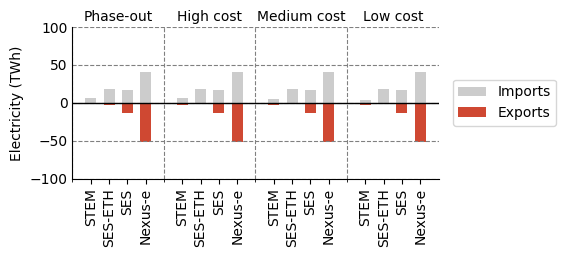

resnuc


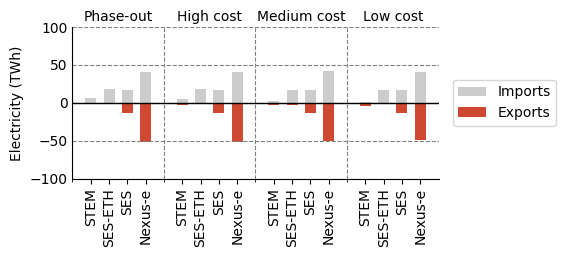

nores


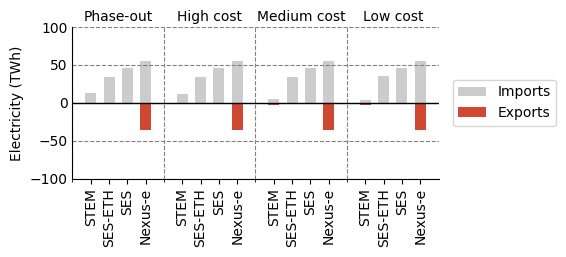

In [28]:
#### Imports and exports
fileName = 'elec_imports'
year = 2050

signedVarList = [
    {
        "name": "Imports",
        "varName": "electricity_supply",
        "techs": ["imports"],
        "sign": +1,
        "color": "#cccccc",
    },
    {
        "name": "Exports",
        "varName": "electricity_consumption",
        "techs": ["exports"],
        "sign": -1,
        "color": "#CF4832",
    },
]

scenario_list={

    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-phaseout','wacc_5'):'Phase-out',
        ('abroad-res-high','wacc_5'):'High cost',
        ('abroad-res-medium','wacc_5'):'Medium cost',
        ('abroad-res-low','wacc_5'):'Low cost',
    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-out',
        ('abroad-resnuc-high','wacc_5'):'High cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium cost',
        ('abroad-resnuc-low','wacc_5'):'Low cost',
    },
        'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-phaseout','wacc_5'):'Phase-out',
        ('abroad-nores-high','wacc_5'):'High cost',
        ('abroad-nores-medium','wacc_5'):'Medium cost',
        ('abroad-nores-low','wacc_5'):'Low cost',
    },
    }

for name, scenarios in scenario_list.items():
    print(name)
    cross_plots.plotBarVerticalSigned(
        listModelsid=listModels,
        listSce=scenarios,
        signedVarList=signedVarList,
        year=year,
        scale=1,
        label="Electricity (TWh)",
        figmax=100,
        fileName=fileName+"_"+name,
        invert=False,
        legend=True,
        #pos_legend="upper right",
        pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
        width=12,
        height=5,
        group_by="scenario",  # or "model"
        multi=False,
    )

## Total Imports

('abroad-resnuc-phaseout', 'wacc_5')


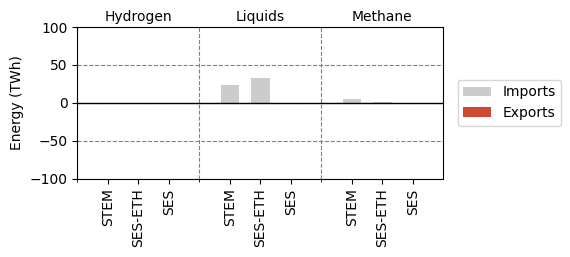

('abroad-resnuc-high', 'wacc_5')


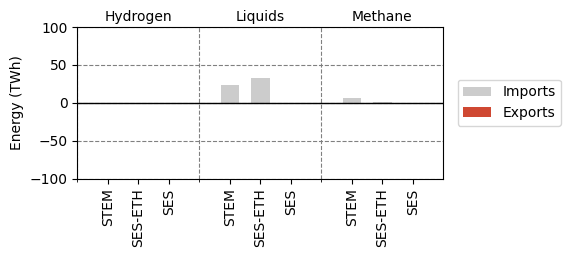

('abroad-resnuc-medium', 'wacc_5')


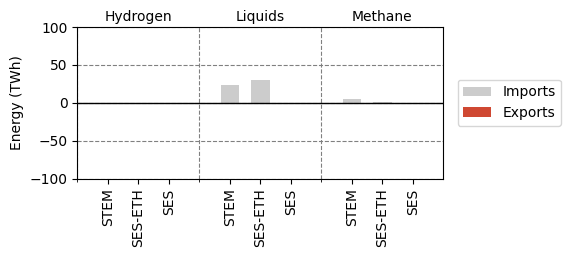

('abroad-resnuc-low', 'wacc_5')


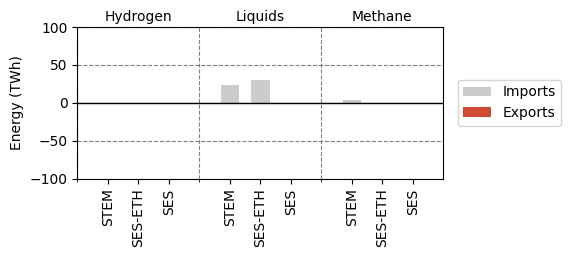

('abroad-res-phaseout', 'wacc_5')


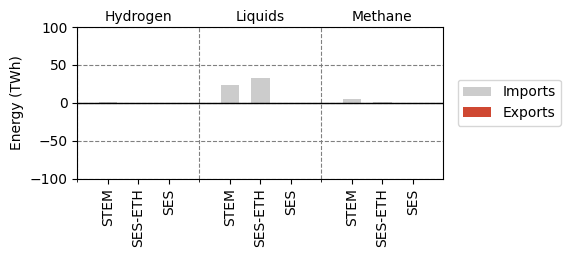

('abroad-res-high', 'wacc_5')


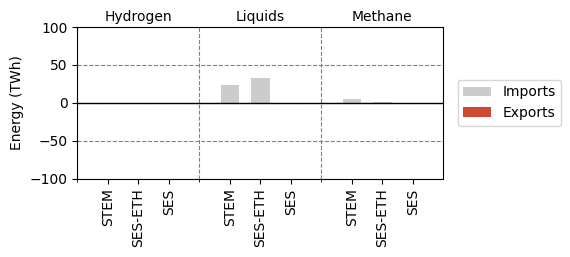

('abroad-res-medium', 'wacc_5')


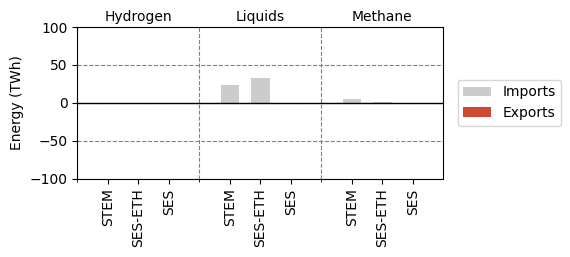

('abroad-res-low', 'wacc_5')


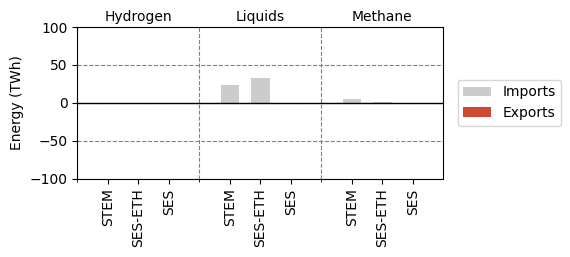

('abroad-nores-phaseout', 'wacc_5')


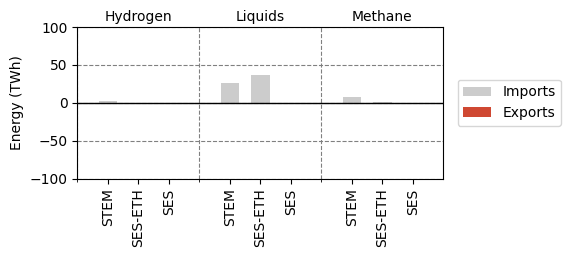

('abroad-nores-high', 'wacc_5')


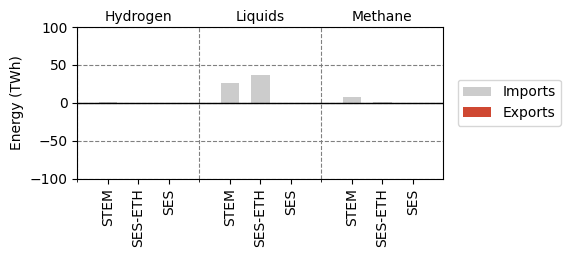

('abroad-nores-medium', 'wacc_5')


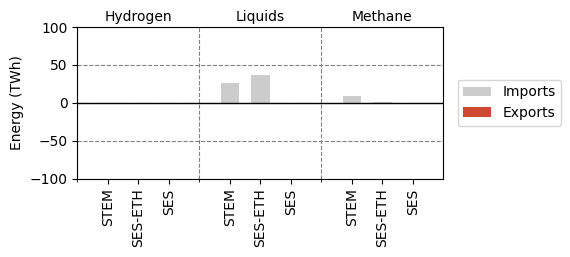

('abroad-nores-low', 'wacc_5')


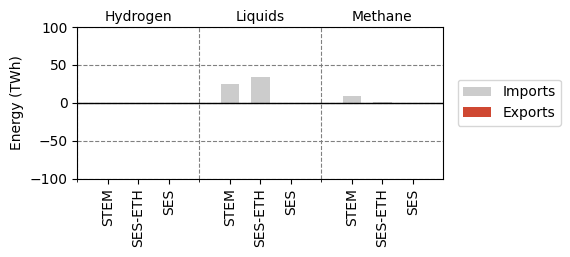

In [12]:
## Total Imports
fileName = 'total_imports'
year = 2050
signedVarByFuel = {
 #   "Electricity": [
 #      {"name": "Imports", "varName": "electricity_supply",      "techs": ["imports"], "sign": +1, "color": "#CCCCCC"},
 #       {"name": "Exports", "varName": "electricity_consumption", "techs": ["exports"], "sign": -1, "color": "#CF4832"},
 #   ],
    "Hydrogen": [
        {"name": "Imports", "varName": "h2_supply", "techs": ["imports"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "h2_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
    "Liquids": [
        {"name": "Imports", "varName": "liquids_supply", "techs": ["imports_diesel","imports_biodiesel"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "liquids_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
    "Methane": [
        {"name": "Imports", "varName": "methane_supply", "techs": ["imports_gas","imports_methane"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "methane_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
}

scenario_list=[
     ('abroad-resnuc-phaseout','wacc_5'),
    ('abroad-resnuc-high','wacc_5'),
    ('abroad-resnuc-medium','wacc_5'),
    ('abroad-resnuc-low','wacc_5'),
    ('abroad-res-phaseout','wacc_5'),
    ('abroad-res-high','wacc_5'),
    ('abroad-res-medium','wacc_5'),
    ('abroad-res-low','wacc_5'),
    ('abroad-nores-phaseout','wacc_5'),
    ('abroad-nores-high','wacc_5'),
    ('abroad-nores-medium','wacc_5'),
    ('abroad-nores-low','wacc_5')

    ]

listModels = cross_plots.modelsid

for scenario in scenario_list:
    print(scenario)
    cross_plots.plotBarVerticalSignedFuels(
      listModelsid=['ses', 'seseth', 'stem'],
      scenario=scenario,
      signedVarByFuel=signedVarByFuel,
      year=2050,
      scale=1,
      label="Energy (TWh)",
      ylim=(-100, 100),
      fileName=fileName+'_'+scenario[0],
      group_by="fuel",
      multi=False,
      legend=True,
      #pos_legend=“upper right”,
      pos_legend={# This puts the legend outside-right for vertical plots
            "loc": "center left",
            "bbox_to_anchor": (1.02, 0.5),
            },
      width=12,
      height=5,
)

